# Assignment 7 — RNN, LSTM and GRU for Sequence Classification

### Objective

Implement and compare **Recurrent Neural Network (RNN), Long Short-Term Memory (LSTM), and Gated Recurrent Unit (GRU)** models for sequence classification using the **IMDB Movie Reviews dataset**.

The models will be trained under a common experimental setup and evaluated using appropriate classification metrics. Their performance will be compared based on **accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, training time, and parameter count**.

### Dataset

**IMDB Movie Reviews Dataset**

* **Task:** Binary sentiment classification
* **Classes:** Positive and Negative
* **Input:** Movie review text
* **Output:** Sentiment label

### Experiment Workflow

1. Load and understand the dataset.
2. Preprocess and tokenize the text sequences.
3. Pad sequences to a common length.
4. Split the data into training, validation, and test sets.
5. Implement RNN, LSTM, and GRU models using a common architecture and training configuration.
6. Train and validate each model using early stopping.
7. Evaluate each model using multiple classification metrics.
8. Visualize training and validation performance.
9. Compare model parameters, training time, and predictive performance.
10. Analyze the results and discuss the differences between RNN, LSTM, and GRU.

## Import Required Libraries

In this step, we import the libraries required for reproducibility, data preprocessing, model development, training, and performance evaluation of the RNN, LSTM, and GRU models.

We have also configure a fixed random seed for Python, NumPy, and TensorFlow to make the experiment as reproducible as possible. TensorFlow deterministic operations are also enabled where supported.

In [1]:
import os
import random
import time

# Reproducibility configuration
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

random.seed(SEED)

import numpy as np
np.random.seed(SEED)
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import (
    GRU,
    LSTM,
    Dense,
    Dropout,
    Embedding,
    Input,
    SimpleRNN,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f"Random seed: {SEED}")
print(f"TensorFlow version: {tf.__version__}")

Random seed: 42
TensorFlow version: 2.21.0


## Verify Hardware Acceleration

In this step, we check whether TensorFlow can detect the available GPU. If a compatible GPU is detected, TensorFlow can use it automatically during model training; otherwise, the experiment can fall back to the CPU.


In [2]:
# Check available GPUs

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"GPU(s) detected: {len(gpus)}")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected. TensorFlow will use the CPU.")

No GPU detected. TensorFlow will use the CPU.


## Load the Official IMDB Dataset

In this step, we load the IMDB Movie Reviews dataset using Keras' official dataset loader. This provides the encoded review sequences and labels using Keras' standard IMDB dataset representation.

In [3]:
# Load the official IMDB dataset through Keras

(train_sequences, train_labels), (test_sequences, test_labels) = imdb.load_data()

print(f"Training samples: {len(train_sequences)}")
print(f"Testing samples: {len(test_sequences)}")

Training samples: 25000
Testing samples: 25000


## Save the Dataset Locally

In this step, we save the dataset loaded by Keras into the project's `data` directory. The directory is created automatically using a relative path, avoiding any machine-specific file locations.

In [4]:
from pathlib import Path

# Create a project-local data directory
DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Define the local dataset path
DATASET_PATH = DATA_DIR / "imdb.npz"

# Save the dataset locally
np.savez(
    DATASET_PATH,
    x_train=np.array(train_sequences, dtype=object),
    y_train=np.array(train_labels),
    x_test=np.array(test_sequences, dtype=object),
    y_test=np.array(test_labels)
)

print(f"Dataset saved to: {DATASET_PATH.resolve()}")

Dataset saved to: D:\College\3rd_Year\DL\Assignments\Assignment 7\data\imdb.npz


## Decode a Sample Review

In this step, we decode one encoded IMDB review using the corresponding IMDB word-index mapping. This allows us to inspect the original review text and its sentiment label before beginning sequence preprocessing.

In [5]:
# Load the IMDB word-index mapping
word_index = imdb.get_word_index()

# Reconstruct the encoded vocabulary
index_to_word = {
    index + 3: word
    for word, index in word_index.items()
}

# Add special tokens
index_to_word.update({
    0: "<PAD>",
    1: "<START>",
    2: "<UNK>"
})


def decode_review(sequence):
    """Convert an encoded IMDB sequence into readable text."""
    return " ".join(
        index_to_word.get(token, "<UNK>")
        for token in sequence
    )


# Decode the first training review
sample_index = 0

print(f"Label: {'Positive' if train_labels[sample_index] == 1 else 'Negative'}")
print(f"Number of tokens: {len(train_sequences[sample_index])}")

print("\nReview")
print("-" * 80)
print(decode_review(train_sequences[sample_index]))

Label: Positive
Number of tokens: 218

Review
--------------------------------------------------------------------------------
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think

### Analyze Review Length Distribution

Before padding the reviews, analyze the distribution of review lengths to choose a suitable maximum sequence length. This helps retain most of the review information while keeping the input size manageable for the recurrent models.

In [6]:
# Calculate the length of each training review
train_lengths = np.array([len(sequence) for sequence in train_sequences])

# Calculate useful length statistics
length_statistics = pd.Series(train_lengths).describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

print("Review Length Statistics")
print("-" * 40)
print(length_statistics)

Review Length Statistics
----------------------------------------
count    25000.000000
mean       238.713640
std        176.497204
min         11.000000
50%        178.000000
75%        291.000000
90%        467.000000
95%        610.000000
99%        926.000000
max       2494.000000
dtype: float64


### Visualize Review Length Distribution

The review-length distribution is visualized to identify the concentration of typical review lengths and the long-tail behavior. The selected maximum sequence length will be used consistently for RNN, LSTM, and GRU.

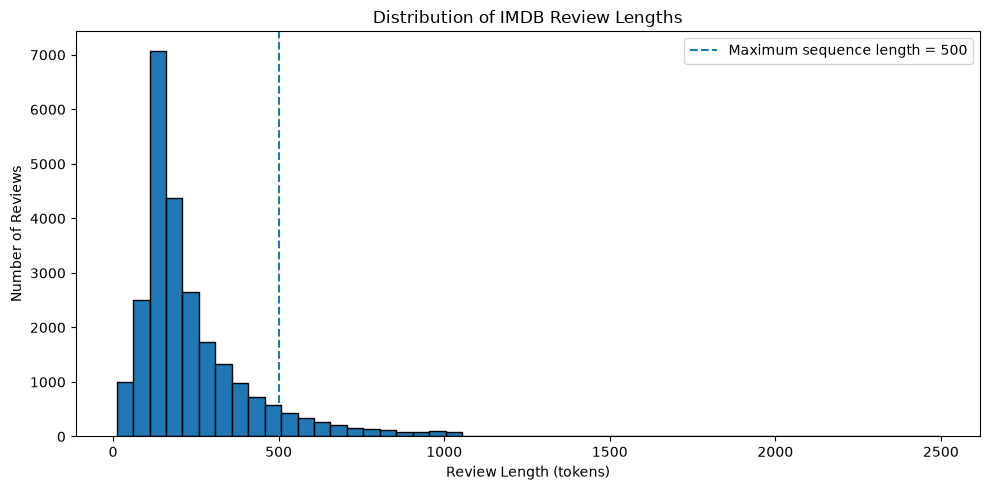

In [7]:
# Visualize the distribution of review lengths

plt.figure(figsize=(10, 5))

plt.hist(
    train_lengths,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    500,
    linestyle="--",
    label="Maximum sequence length = 500"
)

plt.xlabel("Review Length (tokens)")
plt.ylabel("Number of Reviews")
plt.title("Distribution of IMDB Review Lengths")
plt.legend()
plt.tight_layout()
plt.show()

### Define Experiment Configuration

The main preprocessing and training parameters are centralized in one configuration section. Keeping these values together makes the experiment easier to reproduce and ensures that RNN, LSTM, and GRU use the same settings.

In [8]:
# Centralized experiment configuration

VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 500
EMBEDDING_DIM = 128
RECURRENT_UNITS = 64
DROPOUT_RATE = 0.2
BATCH_SIZE = 64
EPOCHS = 15

print("Experiment Configuration")
print("-" * 40)
print(f"Vocabulary size       : {VOCAB_SIZE}")
print(f"Maximum sequence length: {MAX_SEQUENCE_LENGTH}")
print(f"Embedding dimension   : {EMBEDDING_DIM}")
print(f"Recurrent units       : {RECURRENT_UNITS}")
print(f"Dropout rate          : {DROPOUT_RATE}")
print(f"Batch size            : {BATCH_SIZE}")
print(f"Maximum epochs        : {EPOCHS}")

Experiment Configuration
----------------------------------------
Vocabulary size       : 10000
Maximum sequence length: 500
Embedding dimension   : 128
Recurrent units       : 64
Dropout rate          : 0.2
Batch size            : 64
Maximum epochs        : 15


### Apply Vocabulary Limit

The IMDB sequences contain tokens from the full vocabulary, while the experiment uses a vocabulary size of 10,000. Token IDs outside this range are mapped to the `<UNK>` token so that every sequence can be processed by the embedding layer without invalid indices.

In [9]:
# Map token IDs outside the selected vocabulary to <UNK>

def limit_vocabulary(sequences, vocab_size):
    """Replace token IDs outside the vocabulary with the <UNK> token."""
    return [
        [token if token < vocab_size else 2 for token in sequence]
        for sequence in sequences
    ]


train_sequences = limit_vocabulary(train_sequences, VOCAB_SIZE)
test_sequences = limit_vocabulary(test_sequences, VOCAB_SIZE)

print(f"Maximum training token ID: {max(max(sequence) for sequence in train_sequences)}")
print(f"Maximum testing token ID : {max(max(sequence) for sequence in test_sequences)}")
print(f"Allowed token ID range   : 0 to {VOCAB_SIZE - 1}")

Maximum training token ID: 9999
Maximum testing token ID : 9999
Allowed token ID range   : 0 to 9999


### Split Training Data into Training and Validation Sets

The original IMDB training set is divided into training and validation subsets. A stratified split is used to preserve the positive and negative class distribution in both subsets, while the official test set remains untouched for final evaluation.

In [10]:
# Split the original training data into training and validation sets

x_train, x_val, y_train, y_val = train_test_split(
    train_sequences,
    train_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=train_labels
)

print("Dataset Split")
print("-" * 40)
print(f"Training samples   : {len(x_train)}")
print(f"Validation samples : {len(x_val)}")
print(f"Test samples       : {len(test_sequences)}")

print("\nClass Distribution")
print("-" * 40)
print(f"Training   - Negative: {np.sum(y_train == 0)}, Positive: {np.sum(y_train == 1)}")
print(f"Validation - Negative: {np.sum(y_val == 0)}, Positive: {np.sum(y_val == 1)}")
print(f"Test       - Negative: {np.sum(test_labels == 0)}, Positive: {np.sum(test_labels == 1)}")

Dataset Split
----------------------------------------
Training samples   : 20000
Validation samples : 5000
Test samples       : 25000

Class Distribution
----------------------------------------
Training   - Negative: 10000, Positive: 10000
Validation - Negative: 2500, Positive: 2500
Test       - Negative: 12500, Positive: 12500


### Pad Sequences to a Common Length

The reviews have different numbers of tokens, so they are padded or truncated to the selected maximum sequence length of 500 tokens. Post-padding and post-truncation are used consistently across all datasets so that RNN, LSTM, and GRU receive identical input representations.

In [11]:
# Pad and truncate all sequences to the same length

x_train = pad_sequences(
    x_train,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
    value=0
)

x_val = pad_sequences(
    x_val,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
    value=0
)

x_test = pad_sequences(
    test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
    value=0
)

print("Padded Dataset Shapes")
print("-" * 40)
print(f"Training   : {x_train.shape}")
print(f"Validation : {x_val.shape}")
print(f"Test       : {x_test.shape}")

Padded Dataset Shapes
----------------------------------------
Training   : (20000, 500)
Validation : (5000, 500)
Test       : (25000, 500)


### Verify Preprocessed Sequences

Inspect a few padded sequences to verify that valid token IDs are preserved and zero-padding is applied correctly after the original review content.

In [12]:
# Verify the padding of a sample sequence

sample_index = 0
sample_sequence = x_train[sample_index]

non_zero_tokens = np.count_nonzero(sample_sequence)
padding_tokens = np.sum(sample_sequence == 0)

print("Sample Sequence Verification")
print("-" * 40)
print(f"Sequence length       : {len(sample_sequence)}")
print(f"Non-padding tokens    : {non_zero_tokens}")
print(f"Padding tokens        : {padding_tokens}")
print(f"Maximum token ID      : {sample_sequence.max()}")

print("\nFirst 20 tokens:")
print(sample_sequence[:20])

print("\nLast 20 tokens:")
print(sample_sequence[-20:])

Sample Sequence Verification
----------------------------------------
Sequence length       : 500
Non-padding tokens    : 133
Padding tokens        : 367
Maximum token ID      : 7992

First 20 tokens:
[   1  806    8  135   13   28   57  326   51  363    9  399  252  202
  178  102   40 1354  778  449]

Last 20 tokens:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Define Model Architectures

Three sequence classification models are defined using a common architecture to ensure a fair comparison. Each model uses the same embedding layer, number of recurrent units, dropout rate, and output layer. The recurrent layer is the only major architectural difference.

In [13]:
def build_rnn_model():
    """Build the SimpleRNN sentiment classification model."""
    model = Sequential([
        Input(shape=(MAX_SEQUENCE_LENGTH,)),
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True
        ),
        SimpleRNN(RECURRENT_UNITS),
        Dropout(DROPOUT_RATE),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_lstm_model():
    """Build the LSTM sentiment classification model."""
    model = Sequential([
        Input(shape=(MAX_SEQUENCE_LENGTH,)),
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True
        ),
        LSTM(RECURRENT_UNITS),
        Dropout(DROPOUT_RATE),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


def build_gru_model():
    """Build the GRU sentiment classification model."""
    model = Sequential([
        Input(shape=(MAX_SEQUENCE_LENGTH,)),
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True
        ),
        GRU(RECURRENT_UNITS),
        Dropout(DROPOUT_RATE),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Inspect Model Architectures

The three models are instantiated and their parameter counts are inspected before training. This verifies that the models use the intended common configuration while allowing the recurrent layers to differ in their parameter requirements.

In [14]:
# Build the three models

models = {
    "RNN": build_rnn_model(),
    "LSTM": build_lstm_model(),
    "GRU": build_gru_model()
}

# Display model summaries
for model_name, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"{model_name} Model")
    print(f"{'=' * 60}")
    model.summary()

    print(f"Total parameters: {model.count_params():,}")


RNN Model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 500, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 1,317,313


### Configure Early Stopping

Early stopping is used to stop training when validation loss stops improving. The same callback configuration is applied to RNN, LSTM, and GRU to maintain a consistent training procedure and reduce unnecessary training.

In [15]:
# Configure early stopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### Define the Model Training Function

A reusable training function is defined to avoid duplicate code and ensure that RNN, LSTM, and GRU follow the same training procedure. The function also records the training time for later performance comparison.

In [16]:
def train_model(model, model_name):
    """Train a model and record its training time."""
    
    start_time = time.perf_counter()

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=1
    )

    training_time = time.perf_counter() - start_time

    print(f"\n{model_name} training completed.")
    print(f"Training time: {training_time:.2f} seconds")

    return history, training_time

### Train the SimpleRNN Model

The SimpleRNN model is trained on the training set and evaluated on the validation set after each epoch. Early stopping is used to prevent unnecessary training once validation loss stops improving.

In [17]:
# Train the SimpleRNN model

rnn_history, rnn_training_time = train_model(
    models["RNN"],
    "RNN"
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.6485 - loss: 0.6217 - val_accuracy: 0.6872 - val_loss: 0.5851
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.8317 - loss: 0.3916 - val_accuracy: 0.7990 - val_loss: 0.4500
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step - accuracy: 0.8892 - loss: 0.2750 - val_accuracy: 0.7738 - val_loss: 0.5050
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9462 - loss: 0.1496 - val_accuracy: 0.7014 - val_loss: 0.7311
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - accuracy: 0.9731 - loss: 0.0811 - val_accuracy: 0.7738 - val_loss: 0.6653

RNN training completed.
Training time: 162.66 seconds


### Train the LSTM Model

The LSTM model is trained using the same dataset split, batch size, maximum epochs, validation set, and early-stopping configuration used for the other models.

In [18]:
# Train the LSTM model

lstm_history, lstm_training_time = train_model(
    models["LSTM"],
    "LSTM"
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 255ms/step - accuracy: 0.8073 - loss: 0.4178 - val_accuracy: 0.8052 - val_loss: 0.4213
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.8939 - loss: 0.2665 - val_accuracy: 0.8716 - val_loss: 0.3181
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.9257 - loss: 0.1971 - val_accuracy: 0.8720 - val_loss: 0.3267
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - accuracy: 0.8737 - loss: 0.3094 - val_accuracy: 0.8104 - val_loss: 0.4277
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.8431 - loss: 0.3703 - val_accuracy: 0.8134 - val_loss: 0.4459

LSTM training completed.
Training time: 403.91 seconds


### Train the GRU Model

The GRU model is trained using the same dataset split, batch size, maximum epochs, validation set, and early-stopping configuration used for the RNN and LSTM models.

In [19]:
# Train the GRU model

gru_history, gru_training_time = train_model(
    models["GRU"],
    "GRU"
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 194ms/step - accuracy: 0.7865 - loss: 0.4439 - val_accuracy: 0.8234 - val_loss: 0.3973
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.8871 - loss: 0.2819 - val_accuracy: 0.8460 - val_loss: 0.3659
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.9244 - loss: 0.1998 - val_accuracy: 0.8754 - val_loss: 0.3268
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 192ms/step - accuracy: 0.9456 - loss: 0.1504 - val_accuracy: 0.8532 - val_loss: 0.4138
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 192ms/step - accuracy: 0.9654 - loss: 0.0971 - val_accuracy: 0.8726 - val_loss: 0.3792
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 194ms/step - accuracy: 0.9788 - loss: 0.0644 - val_accuracy: 0.8680 - val_loss: 0.4506

GRU training completed.
Training time: 365.16 seconds


### Evaluate Models on the Test Set

The trained models are evaluated on the untouched IMDB test set. A common evaluation function is used to calculate accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix for each model.

In [20]:
def evaluate_model(model, model_name):
    """Evaluate a trained model on the test set."""
    
    # Generate predicted probabilities
    probabilities = model.predict(
        x_test,
        batch_size=BATCH_SIZE,
        verbose=1
    ).ravel()

    # Convert probabilities to binary predictions
    predictions = (probabilities >= 0.5).astype(int)

    # Calculate classification metrics
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }

    # Generate confusion matrix
    cm = confusion_matrix(y_test, predictions)

    return metrics, cm, probabilities, predictions

### Define Test Labels

The original IMDB test labels are assigned to `y_test` to keep the training, validation, and test variable naming consistent throughout the evaluation pipeline.

In [21]:
# Define the test labels for evaluation

y_test = test_labels

print(f"Test samples : {len(x_test)}")
print(f"Test labels  : {len(y_test)}")
print(f"Label values : {np.unique(y_test)}")

Test samples : 25000
Test labels  : 25000
Label values : [0 1]


### Evaluate the RNN Model

The trained SimpleRNN model is evaluated on the untouched test set to measure its generalization performance using the selected classification metrics.

In [22]:
# Evaluate the RNN model

rnn_metrics, rnn_cm, rnn_probabilities, rnn_predictions = evaluate_model(
    models["RNN"],
    "RNN"
)

print("RNN Test Metrics")
print("-" * 40)

for metric, value in rnn_metrics.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

print("\nConfusion Matrix")
print(rnn_cm)

391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step
RNN Test Metrics
----------------------------------------
Accuracy  : 0.7980
Precision : 0.7939
Recall    : 0.8051
F1-Score  : 0.7995
ROC-AUC   : 0.8718

Confusion Matrix
[[ 9887  2613]
 [ 2436 10064]]


In [23]:
# Evaluate the LSTM model

lstm_metrics, lstm_cm, lstm_probabilities, lstm_predictions = evaluate_model(
    models["LSTM"],
    "LSTM"
)

print("LSTM Test Metrics")
print("-" * 40)

for metric, value in lstm_metrics.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

print("\nConfusion Matrix")
print(lstm_cm)

391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step
LSTM Test Metrics
----------------------------------------
Accuracy  : 0.8659
Precision : 0.9011
Recall    : 0.8220
F1-Score  : 0.8597
ROC-AUC   : 0.9403

Confusion Matrix
[[11372  1128]
 [ 2225 10275]]


In [24]:
# Evaluate the GRU model

gru_metrics, gru_cm, gru_probabilities, gru_predictions = evaluate_model(
    models["GRU"],
    "GRU"
)

print("GRU Test Metrics")
print("-" * 40)

for metric, value in gru_metrics.items():
    if metric != "Model":
        print(f"{metric:10s}: {value:.4f}")

print("\nConfusion Matrix")
print(gru_cm)

391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step
GRU Test Metrics
----------------------------------------
Accuracy  : 0.8723
Precision : 0.9037
Recall    : 0.8334
F1-Score  : 0.8671
ROC-AUC   : 0.9423

Confusion Matrix
[[11390  1110]
 [ 2083 10417]]


### Compare Test-Set Performance

The test-set metrics from all three models are combined into a single comparison table. The values are generated directly from the evaluation results to avoid manually entering experimental results.

In [25]:
# Combine test metrics into a comparison DataFrame

results_df = pd.DataFrame([
    rnn_metrics,
    lstm_metrics,
    gru_metrics
])

# Add training time and parameter count
training_times = {
    "RNN": rnn_training_time,
    "LSTM": lstm_training_time,
    "GRU": gru_training_time
}

parameter_counts = {
    "RNN": models["RNN"].count_params(),
    "LSTM": models["LSTM"].count_params(),
    "GRU": models["GRU"].count_params()
}

results_df["Training Time (s)"] = results_df["Model"].map(training_times)
results_df["Parameters"] = results_df["Model"].map(parameter_counts)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s),Parameters
0,RNN,0.79804,0.793879,0.80512,0.799460,0.871764,162.662332,1292417
1,LSTM,0.86588,0.901079,0.82200,0.859725,0.940289,403.906492,1329473
2,GRU,0.87228,0.903704,0.83336,0.867108,0.942255,365.156547,1317313


### Compare Training and Validation Accuracy

Training and validation accuracy are plotted for all three models to compare their learning behavior, convergence, and generalization during training.

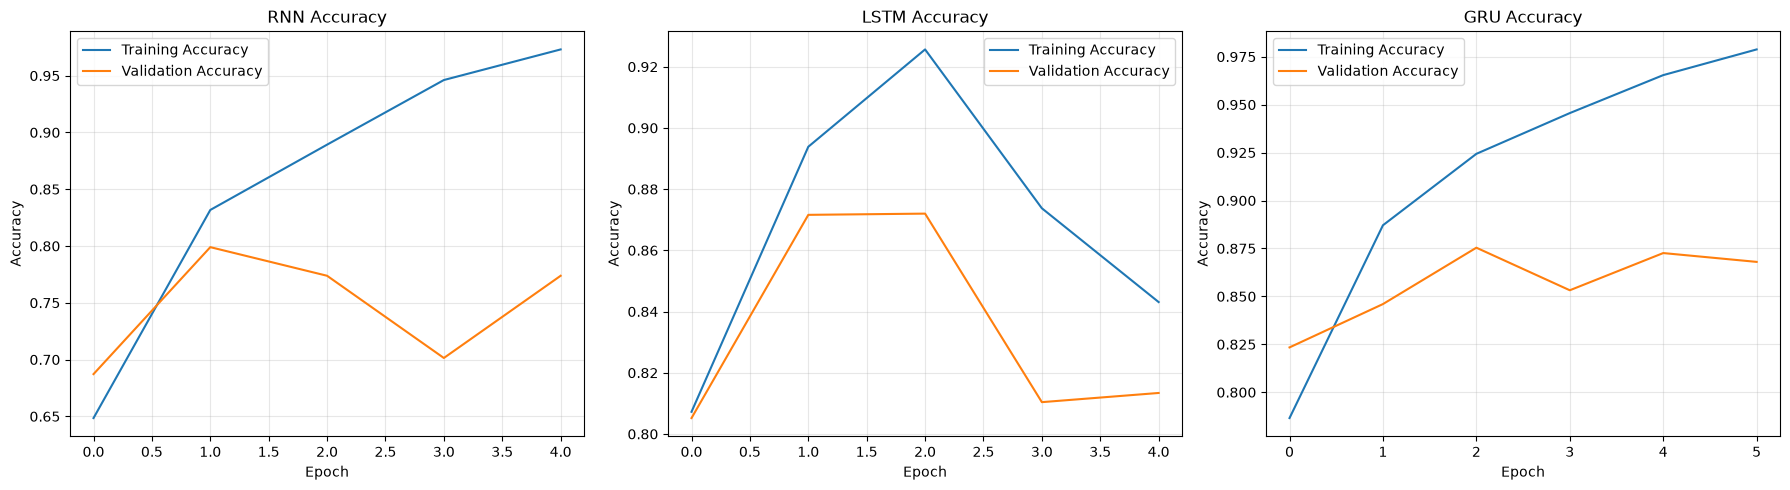

In [26]:
# Plot training and validation accuracy

histories = {
    "RNN": rnn_history,
    "LSTM": lstm_history,
    "GRU": gru_history
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, history) in zip(axes, histories.items()):
    ax.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )
    ax.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    ax.set_title(f"{model_name} Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Compare Training and Validation Loss

Training and validation loss are plotted for all three models to examine convergence and identify signs of overfitting during training.

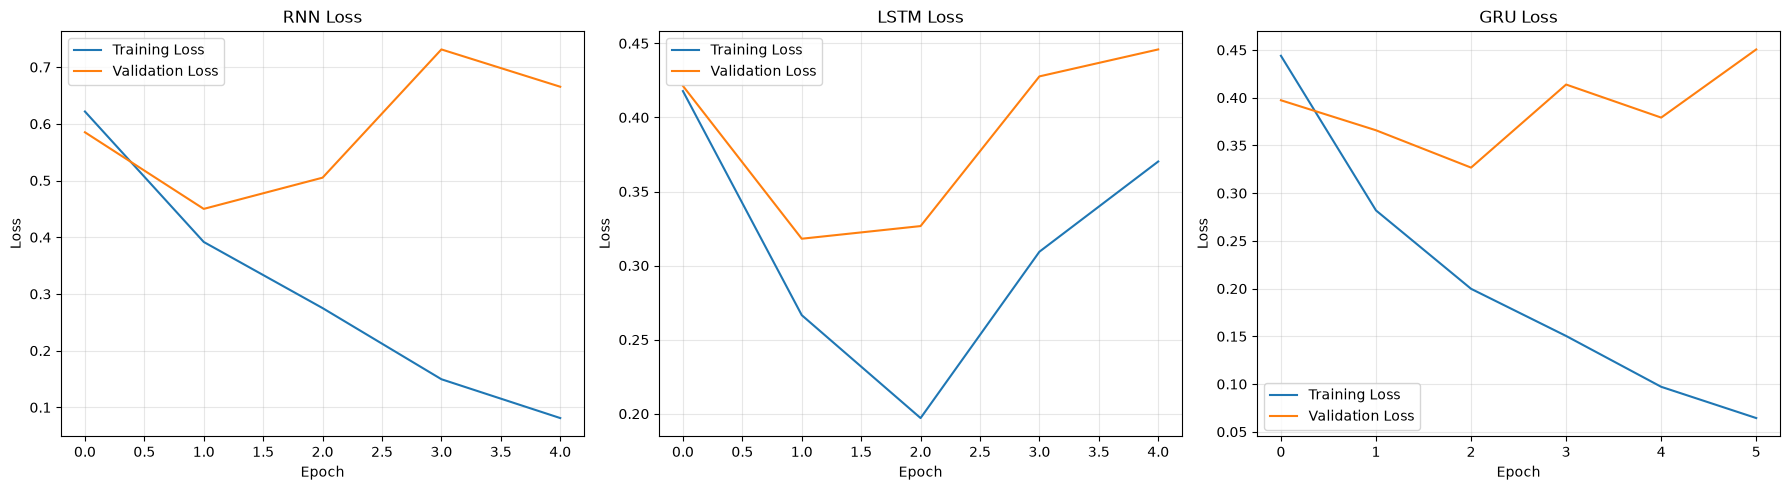

In [27]:
# Plot training and validation loss

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, history) in zip(axes, histories.items()):
    ax.plot(
        history.history["loss"],
        label="Training Loss"
    )
    ax.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    ax.set_title(f"{model_name} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualize Confusion Matrices

Confusion matrices are visualized for the RNN, LSTM, and GRU models to examine the distribution of correct and incorrect predictions across the negative and positive sentiment classes.

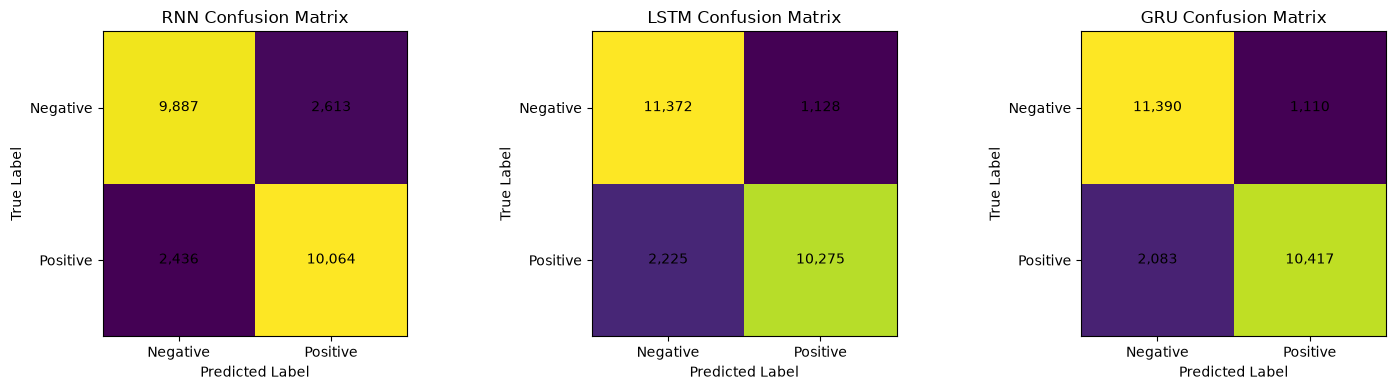

In [28]:
# Plot confusion matrices for all three models

confusion_matrices = {
    "RNN": rnn_cm,
    "LSTM": lstm_cm,
    "GRU": gru_cm
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    ax.imshow(cm)

    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])

    # Display values inside the matrix
    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

### Compare Classification Metrics

The main test-set classification metrics are visualized to compare the predictive performance of the RNN, LSTM, and GRU models across accuracy, precision, recall, F1-score, and ROC-AUC.

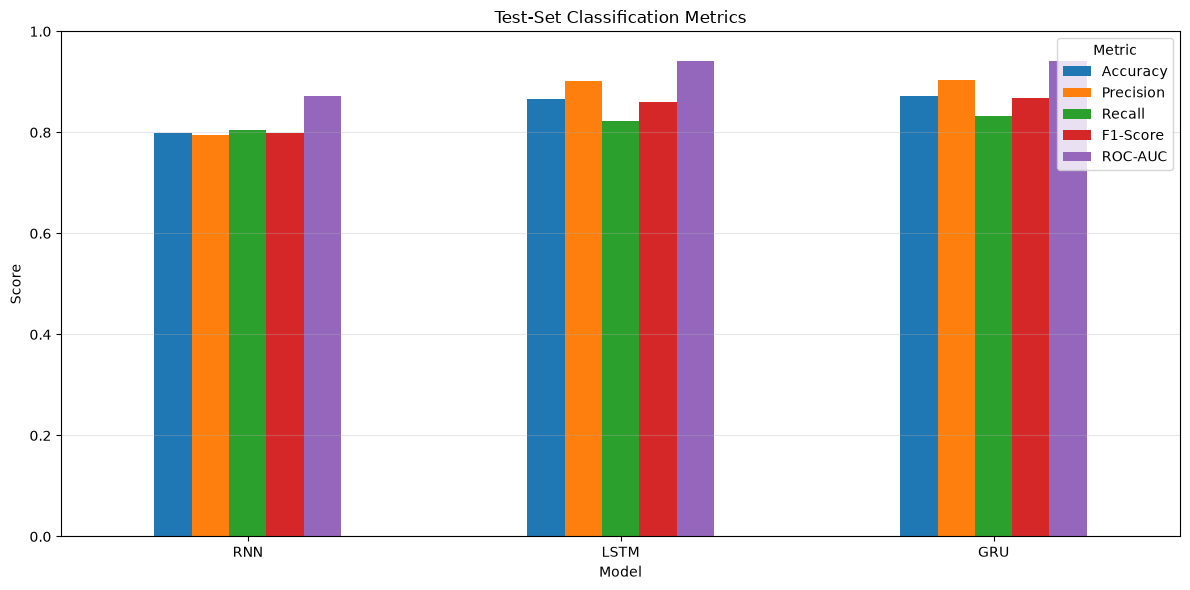

In [29]:
# Plot classification metric comparison

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_df.plot(
    x="Model",
    y=metric_columns,
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Test-Set Classification Metrics")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Compare Model Size

The total number of trainable parameters is compared across the three models to examine the model-size differences introduced by the recurrent architectures.

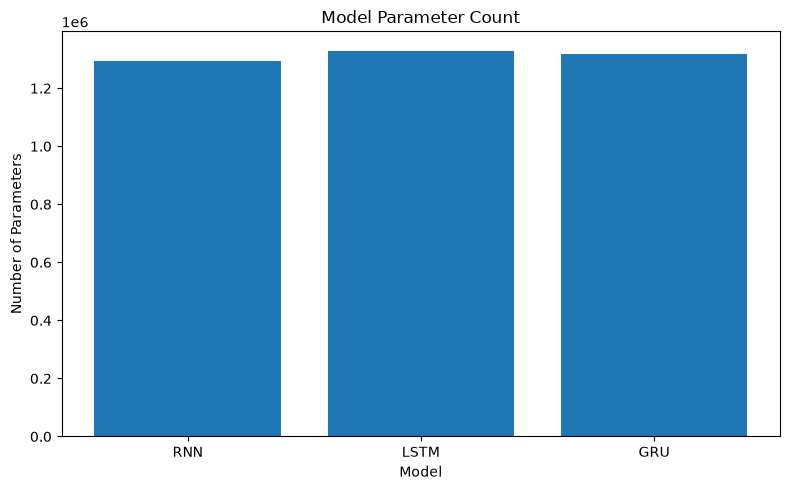

In [30]:
# Plot parameter count comparison

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["Parameters"]
)

plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.title("Model Parameter Count")

plt.tight_layout()
plt.show()

### Final Model Comparison

The final test-set metrics, parameter counts, and measured training times are summarized below. These results are based on the same preprocessing pipeline, data split, model configuration, and evaluation procedure for all three models.

In [31]:
# Create a formatted final comparison table

final_results = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

final_results[metric_columns] = final_results[metric_columns].round(4)
final_results["Training Time (s)"] = final_results["Training Time (s)"].round(2)

final_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s),Parameters
0,RNN,0.7980,0.7939,0.8051,0.7995,0.8718,162.66,1292417
1,LSTM,0.8659,0.9011,0.8220,0.8597,0.9403,403.91,1329473
2,GRU,0.8723,0.9037,0.8334,0.8671,0.9423,365.16,1317313


## Performance Analysis

The three models were evaluated on the same untouched IMDB test set using accuracy, precision, recall, F1-score, and ROC-AUC.

The SimpleRNN achieved an accuracy of 79.80% and an F1-score of 79.95%, with a ROC-AUC of 87.18%.

The LSTM achieved an accuracy of 86.59%, an F1-score of 85.97%, and a ROC-AUC of 94.03%.

The GRU achieved an accuracy of 87.23%, an F1-score of 86.71%, and a ROC-AUC of 94.23%.

In this experiment, the two gated recurrent models achieved higher test-set classification metrics than the SimpleRNN. The LSTM and GRU also produced very similar ROC-AUC values, indicating comparable discrimination performance on the test set.

### Record Best Validation Epoch

Early stopping monitors validation loss, so the restored model weights correspond to the epoch with the lowest validation loss. The best validation epoch is extracted from each training history for accurate reporting.

In [32]:
best_epochs = {}

for model_name, history in histories.items():
    best_epoch = np.argmin(history.history["val_loss"]) + 1
    best_epochs[model_name] = best_epoch

print("Best Validation-Loss Epoch")
print("-" * 40)

for model_name, epoch in best_epochs.items():
    print(f"{model_name}: Epoch {epoch}")

Best Validation-Loss Epoch
----------------------------------------
RNN: Epoch 2
LSTM: Epoch 2
GRU: Epoch 3


## Convergence and Overfitting Analysis

The training curves show that all three models continued to improve on the training data while validation performance eventually stopped improving.

For the SimpleRNN, validation performance reached its best point early and subsequently fluctuated while training accuracy continued to increase. The LSTM and GRU also showed increasing gaps between training and validation performance after their best validation points.

Early stopping therefore prevented unnecessary additional training and restored the model weights corresponding to the best validation loss.

The observed curves indicate that the models were increasingly fitting the training data after their respective best validation points. This behavior highlights the importance of monitoring validation performance rather than training accuracy alone.

## Parameter and Computational Analysis

All three models use the same embedding layer with 1,280,000 parameters. Therefore, most of the difference in total parameter count comes from the recurrent layer.

The SimpleRNN contains 1,292,417 total parameters, while the GRU contains 1,317,313 and the LSTM contains 1,329,473 parameters.

## Conclusion

This experiment implemented and compared SimpleRNN, LSTM, and GRU models for binary sentiment classification using the IMDB Movie Reviews dataset.

Under the common experimental configuration used in this assignment, the SimpleRNN achieved lower test-set performance than the LSTM and GRU. The LSTM and GRU achieved similar results across the evaluated metrics, with the GRU recording 87.23% accuracy, 86.71% F1-score, and 94.23% ROC-AUC in this experiment.

The experiment also demonstrated the trade-off between recurrent architecture complexity, model parameters, and predictive performance. The results show why multiple evaluation metrics and training behavior should be considered when comparing sequence classification models rather than relying on accuracy alone.